# Data Preprocessing

Data preprocessing is one of the most important steps in the Machine Learning pipeline. Raw data is often incomplete, inconsistent, or noisy, making it unsuitable for training machine learning models.

The primary objective of data preprocessing is to clean, transform, and prepare the dataset so that machine learning algorithms can learn meaningful patterns and produce accurate predictions.

In this notebook, we will perform the following preprocessing tasks:

- Import the required libraries
- Load the dataset
- Understand the dataset
- Perform Exploratory Data Analysis (EDA)
- Detect missing values
- Prepare the data for further preprocessing

# Import Required Libraries

The first step is to import the Python libraries that will be used for data manipulation, visualization, and preprocessing throughout this notebook.

In [62]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.model_selection import train_test_split

# Load Dataset

After importing the required libraries, the next step is to load the dataset into a Pandas DataFrame. Pandas provides the `read_csv()` function to read CSV files efficiently. 

And libraries built-in datasets -> directly load 

In [63]:
titanic_data = sns.load_dataset("titanic")

# Display the Dataset

Let's display the first five rows of the dataset to understand its structure and verify that it has been loaded correctly.

In [64]:
titanic_data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


# 1. Data Understanding

Before cleaning or transforming the dataset, it is essential to understand its structure, features, and overall quality.

Data understanding helps identify:

- Number of rows and columns
- Data types of each feature
- Numerical and categorical variables
- Statistical summary
- Missing values
- Overall characteristics of the dataset

## Step 1: Check Dataset Dimensions

The shape of the dataset tells us the total number of rows (observations) and columns (features).

- Rows represent individual records.
- Columns represent different features or variables.

In [65]:
print(f"Rows     :{titanic_data.shape[0]}")
print(f"Columns  :{titanic_data.shape[1]}")
print(f"Rows     :{titanic_data.shape}")

Rows     :891
Columns  :15
Rows     :(891, 15)


## Display Column Names

Viewing the column names helps us understand the available features in the dataset and identify the target variable.

In [66]:
titanic_data.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')

## Dataset Information

The `info()` function provides a concise summary of the dataset, including:

- Number of entries
- Column names
- Data types
- Non-null values
- Memory usage

This is useful for identifying missing values and understanding the structure of the dataset.

In [67]:
titanic_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


## Step 2: Identify Data Types

Each column has a specific data type.

Common data types include:

- int64 → Integer values
- float64 → Decimal values
- object → Text or categorical values
- bool → Boolean values

Understanding data types helps determine the appropriate preprocessing techniques.

In [68]:
titanic_data.dtypes

survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object

## Step 3: Understand Data Nature

### Identify Numerical and Categorical Features

Machine Learning datasets usually contain two main types of variables:

### Numerical Features
These contain numeric values and are used for mathematical calculations.

Examples:
- Age
- Fare
- Salary
- Price

### Categorical Features
These represent categories or labels.

Examples:
- Gender
- City
- Department
- Embarked

In [69]:
numerical_columns = titanic_data.select_dtypes(include=["int64","float64"]).columns

categorical_columns = titanic_data.select_dtypes(include=["object","category"]).columns

print("Numerical Columns \n")
print(numerical_columns)

print("\n Categorical Columns \n")
print(categorical_columns)

Numerical Columns 

Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare'], dtype='str')

 Categorical Columns 

Index(['sex', 'embarked', 'class', 'who', 'deck', 'embark_town', 'alive'], dtype='str')


C:\Users\DELL\AppData\Local\Temp\ipykernel_11848\1489930128.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = titanic_data.select_dtypes(include=["object","category"]).columns


## Step 4: Generate Statistical Summaries

The `describe()` function generates descriptive statistics for numerical features.

It provides:

- Count
- Mean
- Standard Deviation
- Minimum
- 25th Percentile
- Median (50%)
- 75th Percentile
- Maximum

These statistics help understand the distribution and spread of the data.

In [70]:
titanic_data.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Statistical Summary of Categorical Features

For categorical variables, the `describe()` function provides:

- Count
- Number of unique values
- Most frequent value
- Frequency of the most common value

In [71]:
titanic_data.describe(include='object')

C:\Users\DELL\AppData\Local\Temp\ipykernel_11848\2370543876.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  titanic_data.describe(include='object')


,sex,embarked,who,embark_town,alive
count,891,889,891,889,891
unique,2,3,3,3,2
top,male,S,man,Southampton,no
freq,577,644,537,644,549


## Step 5: Create Visualizations

Visualizations make it easier to understand the distribution and relationships within the dataset.

Common visualizations include:

- Histogram
- Scatter Plot
- Pair Plot

### Histogram

A histogram shows the distribution of a numerical feature.

Here, we visualize the distribution of passenger ages.

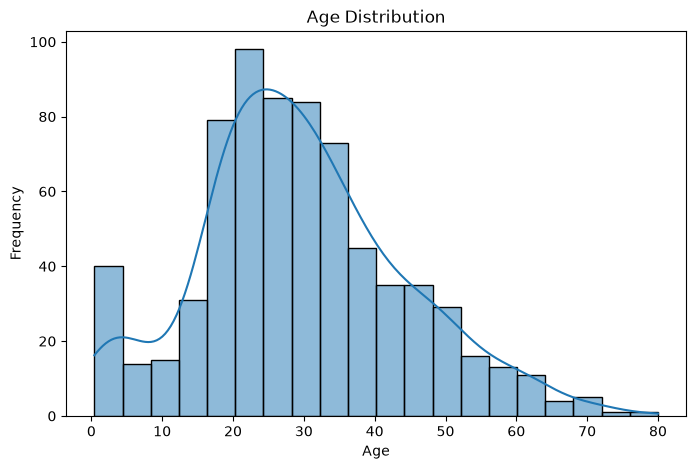

In [72]:
plt.figure(figsize=(8,5))

sns.histplot(titanic_data["age"], kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

### Scatter Plot

A scatter plot is used to examine the relationship between two numerical variables.

In this example, we compare **Age** and **Fare**.

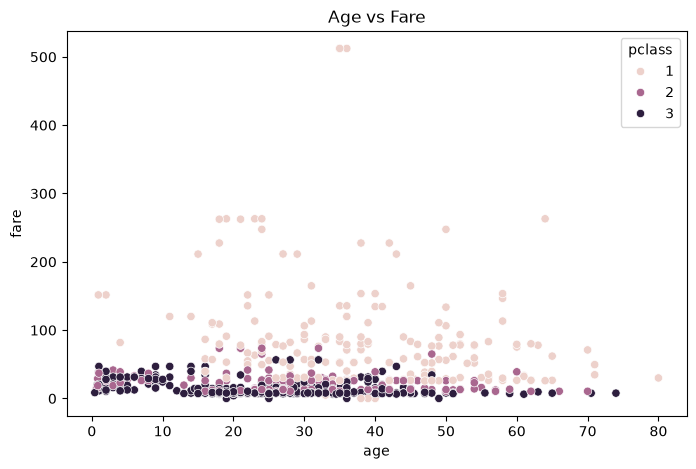

In [73]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=titanic_data, x = "age", y="fare", hue= "pclass")

plt.title("Age vs Fare")
plt.show()

### Pair Plot

A pair plot visualizes the relationship between multiple numerical features simultaneously.

It is useful for identifying trends, correlations, and potential outliers.

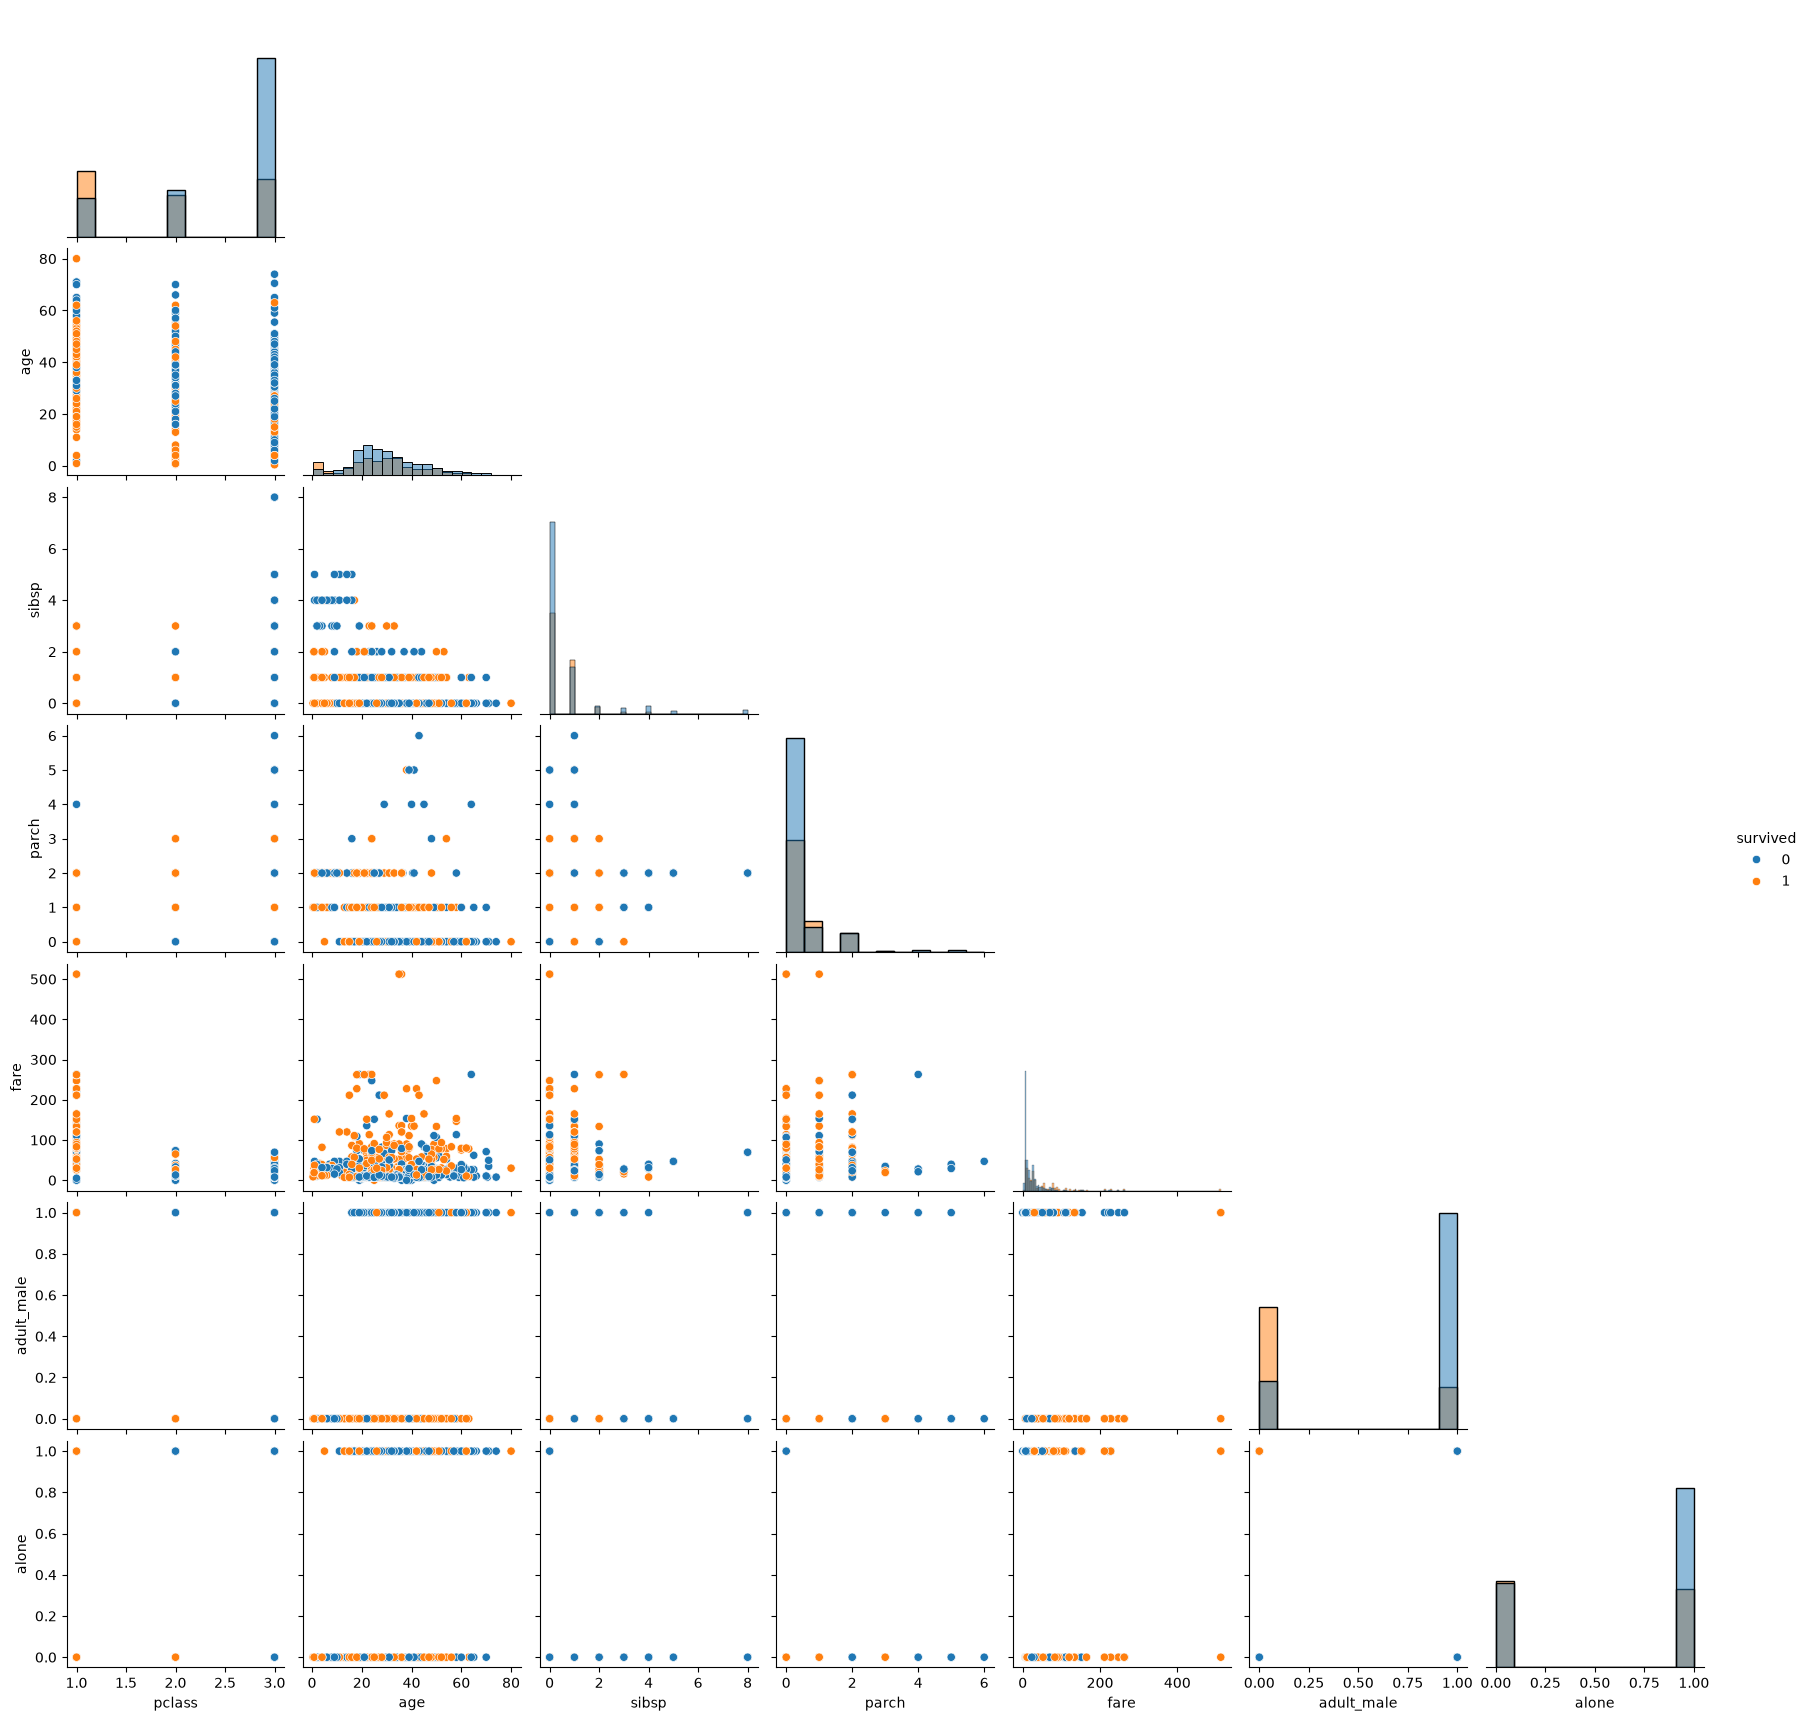

In [74]:
sns.pairplot(titanic_data, hue = "survived", diag_kind = 'hist', corner = True)

plt.show()

# 2. Data Cleaning

Real-world datasets are rarely perfect. They often contain missing values, duplicate records, incorrect data types, and inconsistent data.

Data cleaning is the process of identifying and fixing these issues to improve data quality before training a Machine Learning model.

In this section, we will focus on detecting and handling missing values.

## Missing Values

Missing values occur when no data is stored for a particular observation in a dataset.

These missing values can negatively affect data analysis and machine learning models by introducing bias or reducing model performance.

Therefore, identifying and handling missing values is an essential preprocessing step.

## 2.1 Detect Missing Values

Before handling missing values, we first need to identify which columns contain missing data.

In [75]:
titanic_data.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

- The `isnull()` function checks every cell in the dataset and returns `True` for missing values and `False` otherwise.

- The `sum()` function counts the total number of missing values in each column.

### Calculate Missing Value Percentage

Knowing the percentage of missing values helps determine the most appropriate handling technique.

In [76]:
missing_percentage = (titanic_data.isnull().mean()) * 100

missing_percentage.sort_values(ascending = False)

deck           77.216611
age            19.865320
embarked        0.224467
embark_town     0.224467
sex             0.000000
pclass          0.000000
survived        0.000000
fare            0.000000
parch           0.000000
sibsp           0.000000
class           0.000000
adult_male      0.000000
who             0.000000
alive           0.000000
alone           0.000000
dtype: float64

- A higher percentage of missing values may indicate that the column should be removed or handled using advanced imputation techniques.

### Visualize Missing Values

A heatmap provides a visual representation of missing values across the dataset.

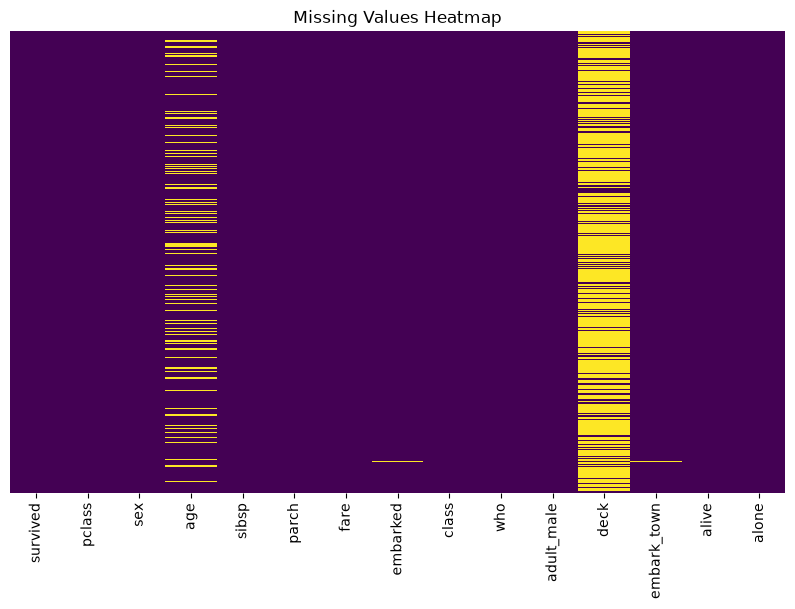

In [77]:
plt.figure(figsize = (10,6))

sns.heatmap(titanic_data.isnull(), cmap = 'viridis', cbar = False, yticklabels = False)

plt.title("Missing Values Heatmap")

plt.show()

- Dark and bright regions in the heatmap indicate where missing values exist, making it easier to identify patterns in the dataset.

## 2.2 Handling Missing Values

After identifying missing values, the next step is to decide how to handle them.

The choice depends on:

- Amount of missing data
- Type of feature
- Nature of the dataset
- Business problem

### Method 1 — Remove Rows

If only a few rows contain missing values, they can be safely removed.

In [78]:
data_cleaned = titanic_data.dropna()

In [79]:
print(data_cleaned.shape)

(182, 15)


- This method removes every row that contains at least one missing value.

- It is suitable only when the number of missing rows is very small.

### Method 2 — Remove Columns

Columns with a large number of missing values may not provide useful information and can be removed.

In [80]:
threshold = len(titanic_data)*0.5

drop_columns = titanic_data.dropna(axis = 1, thresh=threshold)

print(drop_columns.columns)


Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive',
       'alone'],
      dtype='str')


- In this example, columns with more than 50% missing values are removed.

## Numerical Data Imputation

Instead of deleting data, missing numerical values can be replaced using statistical techniques.

### Mean Imputation

Missing values are replaced with the average value of the column.

This technique works well when the data follows a normal distribution and contains very few outliers.

In [81]:
titanic_data['age'] = titanic_data['age'].fillna(titanic_data['age'].mean())

In [82]:
titanic_data.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

### Median Imputation

Missing values are replaced with the median of the column.

Median is preferred when the data contains outliers or follows a skewed distribution.

In [83]:
titanic_data['age'] = titanic_data['age'].fillna(titanic_data['age'].median())

### Mode Imputation

Missing values are replaced with the most frequently occurring value.

Mode can be applied to both numerical and categorical features.

In [84]:
titanic_data['age'] = titanic_data['age'].fillna(titanic_data['age'].mode()[0])

### Group-Based Imputation

Sometimes replacing missing values using the overall mean is not appropriate.

Instead, values can be filled using the average of each group.

In [85]:
titanic_data['age'] = titanic_data.groupby("pclass")["age"].transform(lambda x : x.fillna(x.mean()))


In [86]:
titanic_data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


- Passengers from different classes may have different age distributions. Group-based imputation preserves these differences.

## KNN Imputation

K-Nearest Neighbors (KNN) Imputation estimates missing values using the nearest observations based on feature similarity.

It generally provides better results than simple statistical methods when sufficient related features are available.

In [87]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)

numerical_data = titanic_data.select_dtypes(include=["number"])

titanic_knn = pd.DataFrame(imputer.fit_transform(numerical_data),columns=numerical_data.columns)

titanic_knn.head()

,survived,pclass,age,sibsp,parch,fare
0,0.0,3.0,22.0,1.0,0.0,7.2500
1,1.0,1.0,38.0,1.0,0.0,71.2833
2,1.0,3.0,26.0,0.0,0.0,7.9250
3,1.0,1.0,35.0,1.0,0.0,53.1000
4,0.0,3.0,35.0,0.0,0.0,8.0500


## Categorical Data Imputation

Categorical variables require different techniques because statistical measures like mean and median cannot be applied.

### Fill Missing Values Using Mode

In [88]:
titanic_data["embarked"] = titanic_data["embarked"].fillna(titanic_data["embarked"].mode()[0])


In [89]:
titanic_data.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

- Mode is the most common technique for filling missing values in categorical features.

### Create a New Category

In [90]:
titanic_data["embarked"] = titanic_data["embarked"].fillna("Missing")


- Instead of guessing a value, a new category called **"Missing"** can be created to preserve the information that data was unavailable.

### Most Frequent Imputation Using Scikit-learn

In [91]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy = "most_frequent")

titanic_data["embarked"] = imputer.fit_transform(titanic_data[["embarked"]]).ravel() 


### Advanced Categorical Imputation

In [ ]:
from sklearn.ensemble import RandomForestClassifier

complete_data = titanic_data.dropna(subset=['embarked'])
missing_data = titanic_data[titanic_data['embarked'].isnull()]

rf = RandomForestClassifier()

rf.fit(complete_data[['pclass','fare']], complete_data['embarked'])

missing_data['embarked'] = rf.predict(missing_data[['pclass','fare']])

In [93]:
missing_data.shape

(0, 15)

In [94]:
titanic_data['embarked'].isnull().sum()

np.int64(0)

# Conclusion

In this notebook, we explored the dataset and performed essential data cleaning techniques to prepare it for Machine Learning.

The preprocessing process included understanding the dataset, identifying missing values, and applying appropriate data cleaning methods to improve data quality.

---

> **📝 Note:** A clean and well-understood dataset is the foundation of every successful Machine Learning project. Proper data preparation helps improve model performance and ensures more reliable predictions.

➡️ **Next Notebook:** Outlier Detection and Treatment